# 16 -- Motion triplet-loss embedder (v1)

Same structure as `14_gesture_embedder.ipynb` / `15_tap_embedder.ipynb`
(fixed-identity-set AUC-vs-k, negative control, multi-seed stability,
permutation feature importance, checkpoint caching), retargeted to the
motion modality. Built AFTER the negative-control per-seed leakage fix
(Section 8 below recomputes AND leak-filters the fixed identity set per
shuffle seed, and reports mean/std across 8 seeds rather than 3 -- see
nb14/nb15 session notes for why this matters at this cohort size).

**Baseline note**: `BASELINE_AUC` is loaded directly from
`trust_window_results.csv` at runtime (motality/fixed_across_k rows)
rather than hardcoded, to avoid the stale-baseline problem nb14 hit when
its hand-copied dict fell out of sync with a refreshed harness run.

**Feature count note**: motion has 40 columns in `motion_windows.parquet`
per the last confirmed export (vs. 109 for tap, 118 for gesture) -- far
fewer raw signal channels (accelerometer/orientation only, no spatial/
timing-event features), so a smaller effective feature set after the
0.5-coverage filter is expected here, not a bug.


In [1]:
from pathlib import Path
import hashlib
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.decomposition import PCA

%config InlineBackend.close_figures = False

pd.set_option('display.width', 200); pd.set_option('display.max_columns', 50)
mpl.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25})

def find(*cands):
    for c in cands:
        if Path(c).exists(): return c
    raise FileNotFoundError(cands)

MOD_DIR = Path(find('data/processed/modelling', '../data/processed/modelling', '.'))
motion_path = find(str(MOD_DIR / 'motion_windows.parquet'), 'motion_windows.parquet',
                    '/mnt/user-data/uploads/motion_windows.parquet')
splits_path = find(str(MOD_DIR / 'identity_splits.csv'), 'identity_splits.csv',
                    '/mnt/user-data/uploads/identity_splits.csv')

# OUT_DIR is derived directly from MOD_DIR's parent (data/processed/), NOT
# discovered via find() -- find() only returns paths that already exist, so
# on a first run (this directory doesn't exist yet) it fell through to its
# last literal candidate, '.', which put every output file in the
# notebook's own directory. This was the exact bug that made a gesture
# per_participant.csv turn out byte-identical to tap's own output when
# both notebooks shared a fallback dir with unprefixed filenames --
# deriving OUT_DIR from a path that's guaranteed to exist (MOD_DIR) and
# creating a modality-named subfolder removes the ambiguity entirely.
OUT_DIR = MOD_DIR.parent / 'motion_embedder'
OUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR = OUT_DIR / 'plots'
PLOTS_DIR.mkdir(exist_ok=True)
CKPT_DIR = OUT_DIR / 'checkpoints'
CKPT_DIR.mkdir(exist_ok=True)
print(f"Outputs will be written to: {OUT_DIR.resolve()}")

df = pd.read_parquet(motion_path)
splits = pd.read_csv(splits_path)
df = df.merge(splits[['sessionId', 'role']], on='sessionId', how='inner')
print(f"motion windows: {df.shape}, sessions matched to splits: {df['sessionId'].nunique()}")
print(df.groupby('role').size())


Outputs will be written to: /Users/will/Documents/BBDC-Prototype-2-Research/data/processed/motion_embedder
motion windows: (3291, 41), sessions matched to splits: 94
role
enrol     427
probe     354
train    2510
dtype: int64


## 1. Feature preparation

In [2]:
ID = {'sessionId','participantId','deviceFamily','window_index','window_start_s','window_end_s',
      'taskIndex','taskType','activeArea','task_pass','task_start_s','task_end_s','role'}

feats = [c for c in df.columns if c not in ID and pd.api.types.is_numeric_dtype(df[c])]
coverage = df[feats].notna().mean()
feats = coverage[coverage >= 0.5].index.tolist()
print(f"{len(feats)} features used")

train_df = df[df['role'] == 'train']
imputer = SimpleImputer(strategy='median').fit(train_df[feats])
scaler = StandardScaler().fit(imputer.transform(train_df[feats]))

def embed_input(sub):
    return scaler.transform(imputer.transform(sub[feats])).astype(np.float32)

X_all = embed_input(df)
y_all = df['participantId'].values
role_all = df['role'].values
print(f"X_all: {X_all.shape}")

def data_fingerprint():
    h = hashlib.sha256()
    h.update(X_all.tobytes()); h.update(str(sorted(feats)).encode())
    h.update(role_all.tobytes() if role_all.dtype.kind in 'iuf' else str(list(role_all)).encode())
    return h.hexdigest()[:16]

26 features used
X_all: (3291, 26)


## 2. Batch composition check

participantId
pEAB9GS     32
pCTJ44P     36
pW49U3Q     42
pUNKH7L     46
pZMC82M     51
pEZVKTS     58
pWJGKPK     81
pA6XL23     82
pAFQRTM     92
p3M6E7Z    125
pNDG8LJ    201
pG5G4MS    253
p3YDMHG    418
pH3S4X4    480
p95MPVX    513


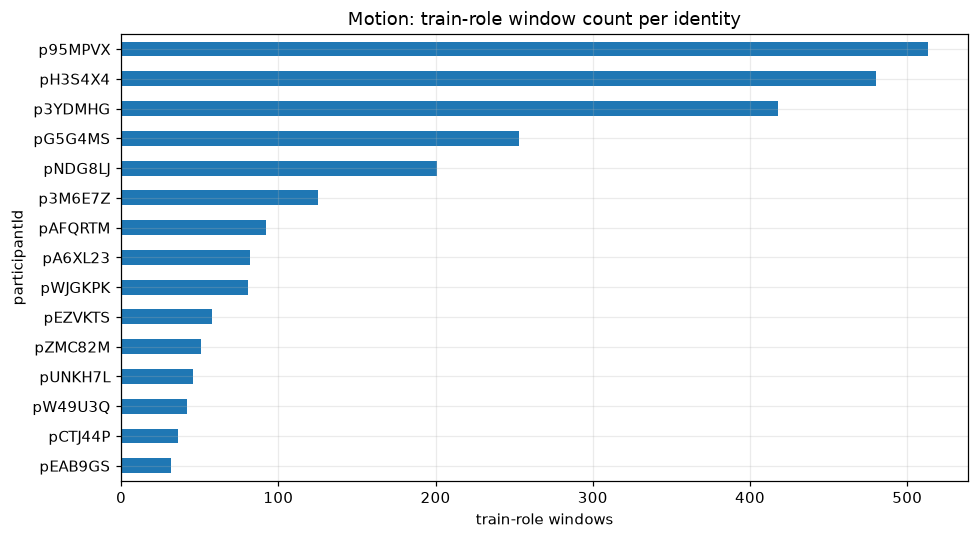


15 identities have train-role data, minimum 32 windows.


In [3]:
train_counts = df[df['role']=='train'].groupby('participantId').size().sort_values()
print(train_counts.to_string())

fig, ax = plt.subplots(figsize=(9, 5))
train_counts.plot(kind='barh', ax=ax)
ax.set_xlabel('train-role windows'); ax.set_title('Motion: train-role window count per identity')
plt.tight_layout()
fig.savefig(PLOTS_DIR / '01_train_windows_per_identity.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{len(train_counts)} identities have train-role data, minimum {train_counts.min()} windows.")


## 3. Batch sampler and model

Architecture unchanged from the gesture notebook (P1's 256-128-32 MLP,
dropout 0.10, L2-normalised output, batch-all triplet loss, margin 0.20).
Same capped-batches-per-epoch speed fix and checkpoint cache as nb14.

In [4]:
IDENTITIES_PER_BATCH = 2
WINDOWS_PER_IDENTITY = 4
MARGIN = 0.20
EMBED_DIM = 32
EPOCHS = 40
LR = 1e-4
WEIGHT_DECAY = 1e-4
MAX_BATCHES_PER_EPOCH = 150

class BalancedIdentityBatchSampler(torch.utils.data.Sampler):
    def __init__(self, labels, identities_per_batch, windows_per_identity,
                 max_batches=MAX_BATCHES_PER_EPOCH, seed=0):
        self.by_identity = {pid: np.where(labels == pid)[0] for pid in np.unique(labels)}
        self.eligible = [pid for pid, idx in self.by_identity.items()
                          if len(idx) >= windows_per_identity]
        self.k, self.m = identities_per_batch, windows_per_identity
        self.rng = np.random.default_rng(seed)
        natural = max(1, sum(len(v) for v in self.by_identity.values()) // (self.k * self.m))
        self.n_batches = min(natural, max_batches)

    def __iter__(self):
        for _ in range(self.n_batches):
            pids = self.rng.choice(self.eligible, size=self.k, replace=False)
            batch = []
            for pid in pids:
                idx = self.by_identity[pid]
                chosen = self.rng.choice(idx, size=self.m, replace=len(idx) < self.m)
                batch.extend(chosen.tolist())
            yield batch

    def __len__(self):
        return self.n_batches


class Embedder(nn.Module):
    def __init__(self, in_dim, embed_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256), nn.ReLU(), nn.Dropout(0.10),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.10),
            nn.Linear(128, embed_dim),
        )
    def forward(self, x):
        return nn.functional.normalize(self.net(x), p=2, dim=1)


def batch_all_triplet_loss(embeddings, labels, margin=MARGIN):
    dist = torch.cdist(embeddings, embeddings, p=2)
    labels = labels.unsqueeze(0)
    same = (labels == labels.T)
    eye = torch.eye(len(labels[0]), dtype=torch.bool, device=embeddings.device)
    pos_mask, diff = same & ~eye, ~same

    losses = []
    for a in range(len(embeddings)):
        pos_d, neg_d = dist[a][pos_mask[a]], dist[a][diff[a]]
        if len(pos_d) == 0 or len(neg_d) == 0:
            continue
        l = torch.clamp(pos_d.unsqueeze(1) - neg_d.unsqueeze(0) + margin, min=0)
        losses.append(l.flatten())
    if not losses:
        return torch.tensor(0.0, requires_grad=True), 0.0
    all_losses = torch.cat(losses)
    active = all_losses[all_losses > 0]
    return all_losses.mean(), (active.numel() / max(all_losses.numel(), 1))

print(f"input dim {len(feats)}, embedding dim {EMBED_DIM}, "
      f"up to {MAX_BATCHES_PER_EPOCH} batches/epoch")

input dim 26, embedding dim 32, up to 150 batches/epoch


## 4. Training, with a checkpoint cache

Same `FORCE_RETRAIN = False` cache-by-data-fingerprint pattern as nb14.

In [5]:
FORCE_RETRAIN = True

def train_embedder(X, y, role, seed=0, epochs=EPOCHS, verbose=True):
    torch.manual_seed(seed)
    train_mask = role == 'train'
    X_train, y_train = X[train_mask], y[train_mask]
    model = Embedder(X.shape[1], EMBED_DIM)
    opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sampler = BalancedIdentityBatchSampler(y_train, IDENTITIES_PER_BATCH, WINDOWS_PER_IDENTITY, seed=seed)
    history = {'epoch': [], 'loss': [], 'active_frac': []}
    for epoch in range(epochs):
        model.train()
        epoch_losses, epoch_actives = [], []
        for batch_idx in sampler:
            xb = torch.tensor(X_train[batch_idx])
            yb = torch.tensor(pd.factorize(y_train[batch_idx])[0])
            opt.zero_grad()
            emb = model(xb)
            loss, active_frac = batch_all_triplet_loss(emb, yb)
            loss.backward(); opt.step()
            epoch_losses.append(loss.item()); epoch_actives.append(active_frac)
        history['epoch'].append(epoch)
        history['loss'].append(np.mean(epoch_losses))
        history['active_frac'].append(np.mean(epoch_actives))
        if verbose and (epoch % 5 == 0 or epoch == epochs - 1):
            print(f"  epoch {epoch:2d}  loss={history['loss'][-1]:.4f}  active_frac={history['active_frac'][-1]:.3f}")
    return model, pd.DataFrame(history)

fp = data_fingerprint()
ckpt_path = CKPT_DIR / f'primary_seed42_{fp}.pt'
if ckpt_path.exists() and not FORCE_RETRAIN:
    print(f"Loading cached model (fingerprint {fp}) -- set FORCE_RETRAIN=True to retrain.")
    ckpt = torch.load(ckpt_path, weights_only=False)
    model = Embedder(len(feats), EMBED_DIM)
    model.load_state_dict(ckpt['state_dict'])
    history = ckpt['history']
else:
    print("Training real-label model (seed=42)...")
    model, history = train_embedder(X_all, y_all, role_all, seed=42)
    torch.save({'state_dict': model.state_dict(), 'history': history}, ckpt_path)
    print(f"Cached to {ckpt_path.name}")

Training real-label model (seed=42)...
  epoch  0  loss=0.1335  active_frac=0.629
  epoch  5  loss=0.1008  active_frac=0.487
  epoch 10  loss=0.0962  active_frac=0.470
  epoch 15  loss=0.0790  active_frac=0.404
  epoch 20  loss=0.0742  active_frac=0.372
  epoch 25  loss=0.0709  active_frac=0.359
  epoch 30  loss=0.0665  active_frac=0.325
  epoch 35  loss=0.0665  active_frac=0.321
  epoch 39  loss=0.0655  active_frac=0.331
Cached to primary_seed42_9356c6ce49e05714.pt


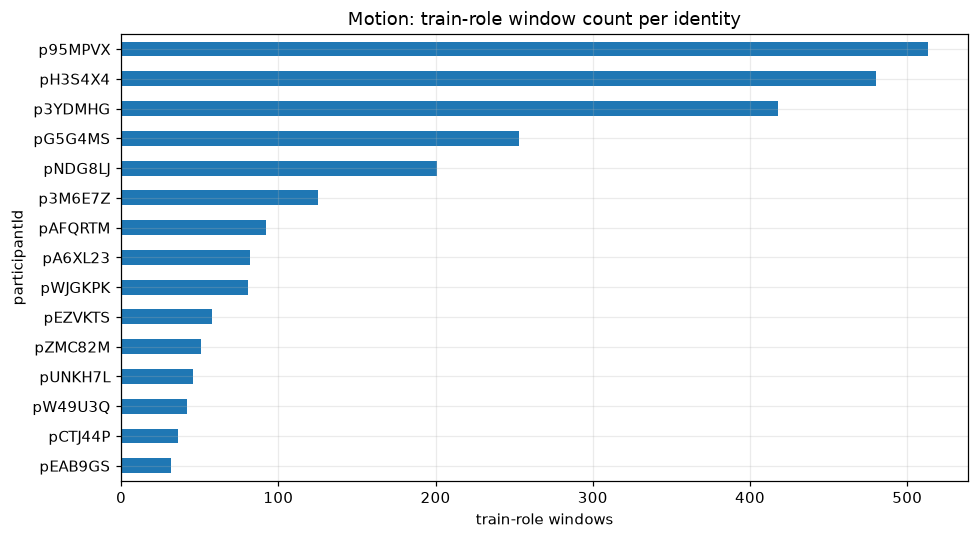

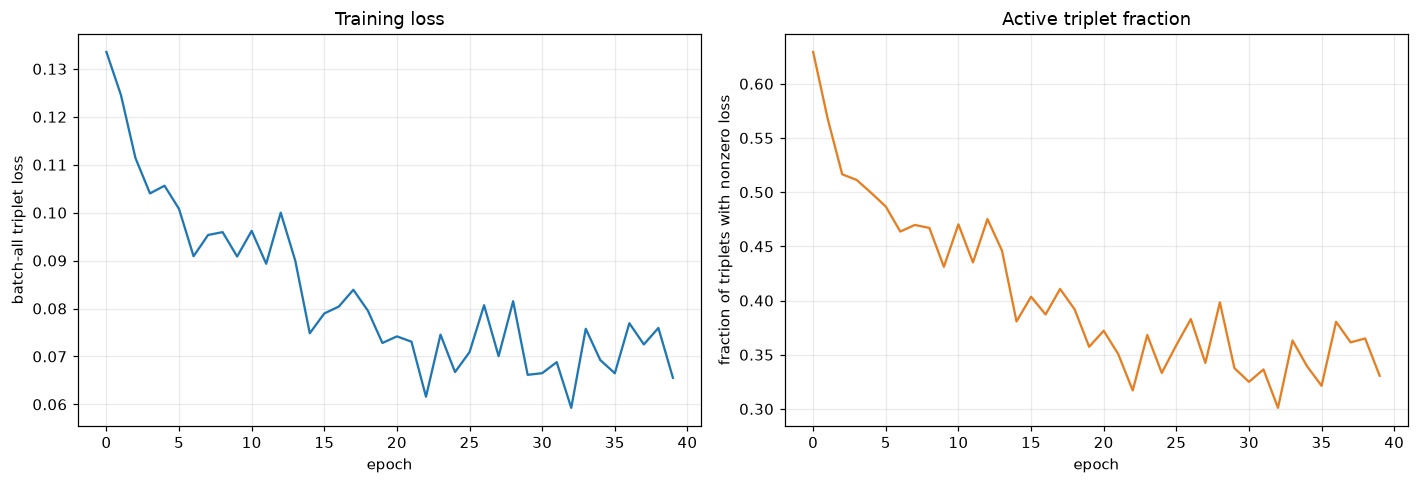

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(history['epoch'], history['loss'])
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('batch-all triplet loss'); axes[0].set_title('Training loss')
axes[1].plot(history['epoch'], history['active_frac'], color='#e67e22')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('fraction of triplets with nonzero loss')
axes[1].set_title('Active triplet fraction')
plt.tight_layout()
fig.savefig(PLOTS_DIR / '02_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Evaluation -- fixed identity set

Same fixed-vs-all-available identity-set split as nb14, to avoid the
survivorship confound where the probe-identity set shrinks as k grows.

In [7]:
def compute_metrics(y_true, scores):
    if len(np.unique(y_true)) < 2:
        return {'auc': np.nan, 'eer': np.nan, 'far_at_10pct_frr': np.nan}
    auc = roc_auc_score(y_true, scores)
    fpr, tpr, _ = roc_curve(y_true, scores)
    frr = 1 - tpr
    idx = int(np.nanargmin(np.abs(fpr - frr)))
    eer = float((fpr[idx] + frr[idx]) / 2)
    far10 = float(np.interp(0.90, tpr, fpr))
    return {'auc': float(auc), 'eer': eer, 'far_at_10pct_frr': far10}

def embed(model, X):
    model.eval()
    with torch.no_grad():
        return model(torch.tensor(X)).numpy()

def score_probe_windows(E, y, df_meta, role, k_values):
    """Long-form scored rows: one per (k, probe_pid, candidate, trust-window
    instance). trust_id lets cohort normalisation and per-identity breakdown
    both work off the same table. Each trust window also carries its actual
    elapsed wall-clock span (span_s = end of its last window minus start of
    its first), computed from real window_start_s/window_end_s rather than
    assumed from k and a window-length/stride constant -- the same approach
    evaluate_trust_windows.py's build_trust_windows() uses, and deliberately
    so: the window-length/stride decision for P2's pipeline is still
    unresolved, so nothing here should assume a specific value for either."""
    enrol_mask, probe_mask = role == 'enrol', role == 'probe'
    refs = {pid: E[enrol_mask & (y == pid)].mean(axis=0) for pid in np.unique(y[enrol_mask])}
    rows = []
    for pid in np.unique(y[probe_mask]):
        idx = np.where(probe_mask & (y == pid))[0]
        order = np.argsort(df_meta.loc[idx, 'window_start_s'].values)
        idx_ordered = idx[order]
        Ep = E[idx_ordered]
        starts = df_meta.loc[idx_ordered, 'window_start_s'].values
        ends = df_meta.loc[idx_ordered, 'window_end_s'].values
        for k in k_values:
            if len(Ep) < k: continue
            for i in range(len(Ep) - k + 1):
                agg = Ep[i:i+k].mean(axis=0)
                span_s = float(ends[i + k - 1] - starts[i])
                for cand, ref in refs.items():
                    rows.append({'k': k, 'pid': pid, 'cand': cand, 'genuine': int(cand == pid),
                                 'dist': float(np.linalg.norm(agg - ref)),
                                 'trust_id': f'{pid}|{i}|{k}', 'span_s': span_s})
    return pd.DataFrame(rows), refs

def summarise(scored, fixed_identities=None, label=''):
    """Cohort-normalised AUC/EER/FAR@10%FRR per k (and per identity),
    optionally restricted to a fixed identity set. median_span_s reports
    each k's actual elapsed wall-clock time (median across trust windows,
    empirical -- see score_probe_windows docstring), a cheap way to read
    the AUC-vs-k curve as a detection-latency curve without assuming a
    window-length/stride value that hasn't been decided yet. Per-identity
    rows now also carry EER, not just AUC -- diagnostic colour for
    flagging outliers alongside the leave-one-out check, not a headline
    number (per-single-identity EER is the most extreme version of the
    small-N instability this project has spent real time diagnosing --
    read it with the same caution as any low-comparison-count result)."""
    if fixed_identities is not None:
        scored = scored[scored['pid'].isin(fixed_identities)]
    per_k, per_identity = [], []
    for k, g in scored.groupby('k'):
        g = g.copy()
        g['z'] = g.groupby('trust_id')['dist'].transform(
            lambda s: (s - s.mean()) / (s.std() if s.std() > 0 else 1))
        median_span_s = g.drop_duplicates('trust_id')['span_s'].median()
        per_k.append({'k': k, 'identity_set': label, 'n_probe_identities': g['pid'].nunique(),
                       'n_trust_windows': g['trust_id'].nunique(), 'median_span_s': median_span_s,
                       **compute_metrics(g['genuine'], -g['z'])})
        for pid, gp in g.groupby('pid'):
            if gp['genuine'].nunique() < 2: continue
            pid_metrics = compute_metrics(gp['genuine'], -gp['z'])
            per_identity.append({'k': k, 'identity_set': label, 'participantId': pid,
                                  'auc': pid_metrics['auc'], 'eer': pid_metrics['eer'],
                                  'n_comparisons': len(gp)})
    return pd.DataFrame(per_k), pd.DataFrame(per_identity)

k_values = [1, 2, 3, 5, 8, 10, 15, 20]
E_all = embed(model, X_all)
df_idx = df.reset_index(drop=True)
scored, refs = score_probe_windows(E_all, y_all, df_idx, role_all, k_values)
print(f"{len(refs)} reference identities, {len(scored)} scored rows")

res_all, per_id_all = summarise(scored, fixed_identities=None, label='all_available')

max_k = max(k_values)
probe_counts = df_idx[df_idx['role']=='probe'].groupby('participantId').size()
fixed_identities = set(probe_counts[probe_counts >= max_k].index) & set(refs.keys())
print(f"{len(fixed_identities)} identities have >= {max_k} probe windows: {sorted(fixed_identities)}")

if len(fixed_identities) >= 2:
    res_fixed, per_id_fixed = summarise(scored, fixed_identities=fixed_identities, label='fixed_across_k')
    res_df = pd.concat([res_all, res_fixed], ignore_index=True)
    per_id_df = pd.concat([per_id_all, per_id_fixed], ignore_index=True)
else:
    # Do NOT append a duplicate copy of res_all/per_id_all here. An earlier
    # version did (`res_fixed, per_id_fixed = res_all.copy(), ...`), but
    # that copy's identity_set column still read 'all_available' rather
    # than being relabeled -- concatenating it onto res_all silently
    # duplicated every row. Went unnoticed because every prior consumer
    # filtered specifically on identity_set=='fixed_across_k' (empty in
    # this branch, so nothing showed); Section 6's elapsed-time table was
    # the first thing to display whatever label IS present, which is what
    # surfaced it on typing. Leaving res_df/per_id_df as exactly res_all/
    # per_id_all (no fixed_across_k rows at all) is both correct and
    # already what every downstream .empty / .any() check expects.
    print("WARNING: fewer than 2 identities qualify for the fixed set -- reporting all_available only.")
    res_df = res_all.copy()
    per_id_df = per_id_all.copy()

print()
print(res_df[res_df['identity_set']=='fixed_across_k']
      [['k','n_probe_identities','median_span_s','auc','eer']].to_string(index=False, float_format=lambda v:f'{v:.3f}'))

12 reference identities, 26004 scored rows
9 identities have >= 20 probe windows: ['p3M6E7Z', 'p3YDMHG', 'p95MPVX', 'pAFQRTM', 'pEZVKTS', 'pH3S4X4', 'pNDG8LJ', 'pUNKH7L', 'pWS9VTN']

 k  n_probe_identities  median_span_s   auc   eer
 1                   9         15.000 0.793 0.269
 2                   9         22.500 0.811 0.253
 3                   9         30.000 0.825 0.241
 5                   9         45.000 0.844 0.226
 8                   9         67.500 0.856 0.224
10                   9         82.500 0.857 0.220
15                   9        120.000 0.876 0.193
20                   9        157.500 0.901 0.172


## 5b. Leave-one-out dominance check

Mirrors `evaluate_trust_windows.py`'s leave-one-out logic. Recomputes
cohort-normalised AUC with each fixed-set identity held out in turn -- a
single identity dominating (or dragging down) the pooled number would
otherwise only be visible by manually scanning `per_identity` output,
which is exactly how `pUNKH7L`'s near-chance tap result (AUC 0.455 at
k=20, hidden inside a pooled 0.944) went unnoticed in nb15 until asked
for directly. Run at k=20 (the headline k), on the fixed identity set.


In [8]:
def leave_one_out_auc(scored, fixed_identities, k):
    base = scored[(scored['k']==k) & scored['pid'].isin(fixed_identities)]
    results = {}
    for pid_out in sorted(fixed_identities):
        sub = base[base['pid'] != pid_out].copy()
        if sub['genuine'].nunique() < 2:
            continue
        sub['z'] = sub.groupby('trust_id')['dist'].transform(
            lambda s: (s - s.mean()) / (s.std() if s.std() > 0 else 1))
        results[pid_out] = roc_auc_score(sub['genuine'], -sub['z'])
    return results

LOO_K = 20
loo = leave_one_out_auc(scored, fixed_identities, LOO_K)
full_auc = res_df[(res_df['identity_set']=='fixed_across_k') & (res_df['k']==LOO_K)]['auc'].iloc[0]

loo_df = pd.DataFrame(sorted(loo.items(), key=lambda kv: kv[1]),
                       columns=['identity_removed', 'auc_without_them'])
loo_df['shift_from_full'] = loo_df['auc_without_them'] - full_auc
print(f"Full fixed-set AUC at k={LOO_K}: {full_auc:.3f}\n")
print(loo_df.to_string(index=False, float_format=lambda v: f'{v:.3f}'))

worst_shift = loo_df['shift_from_full'].abs().max()
if worst_shift > 0.03:
    dominant = loo_df.loc[loo_df['shift_from_full'].abs().idxmax(), 'identity_removed']
    print(f"\nFLAG: removing {dominant} shifts pooled AUC by "
          f"{loo_df['shift_from_full'].abs().max():+.3f} -- check that identity's "
          f"per-participant AUC directly before treating the pooled k={LOO_K} number as representative.")

Full fixed-set AUC at k=20: 0.901

identity_removed  auc_without_them  shift_from_full
         p3M6E7Z             0.810           -0.091
         p95MPVX             0.895           -0.006
         pUNKH7L             0.899           -0.002
         p3YDMHG             0.899           -0.002
         pWS9VTN             0.904            0.003
         pEZVKTS             0.905            0.004
         pNDG8LJ             0.907            0.006
         pAFQRTM             0.912            0.011
         pH3S4X4             0.944            0.043

FLAG: removing p3M6E7Z shifts pooled AUC by +0.091 -- check that identity's per-participant AUC directly before treating the pooled k=20 number as representative.


## 6. Trained embedder vs raw-distance baseline

`BASELINE_AUC` is loaded directly from `trust_window_results.csv` at
runtime (motion / `fixed_across_k` / `auc_cohort_norm` rows) rather
than hand-copied into a dict, which avoids the stale-baseline problem an
earlier version of this notebook hit when a hand-copied dict fell out of
sync with a refreshed harness run. If this cell prints a "no rows found"
warning, re-run `evaluate_trust_windows.py` first -- the overlay just
won't show baseline points until that file has motion rows in it.


Loaded baseline AUC for k=[1, 2, 3, 5, 8, 10, 15, 20] from ../data/processed/modelling/trust_window_results.csv


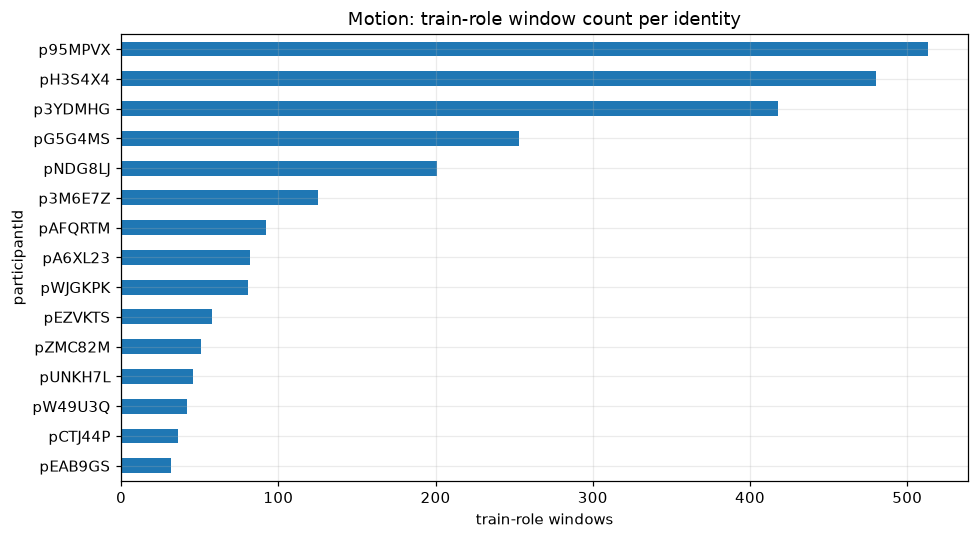

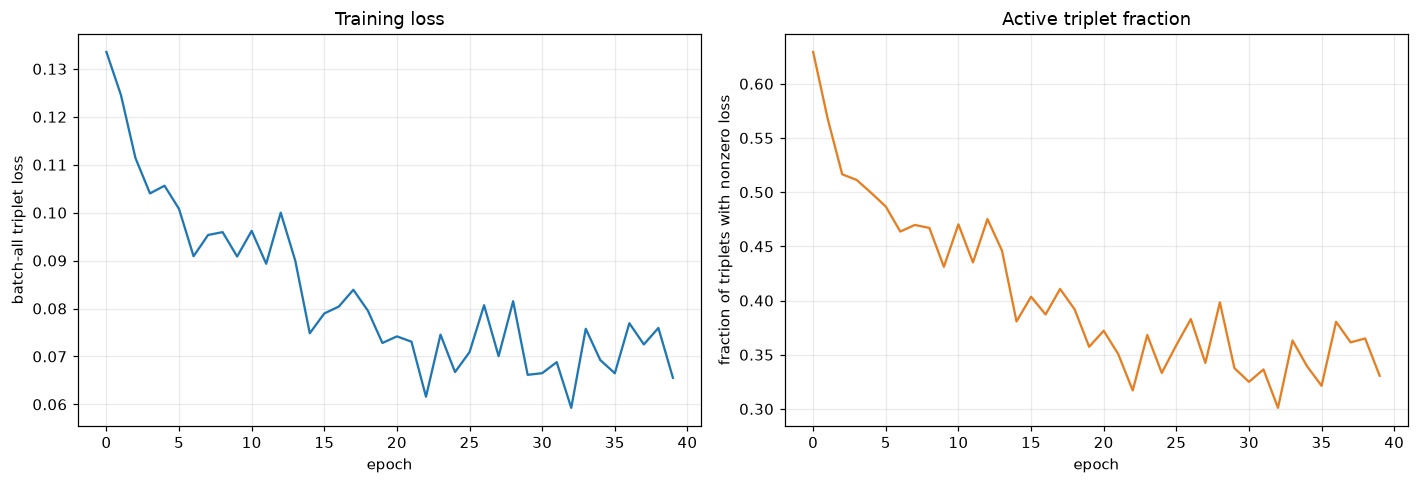

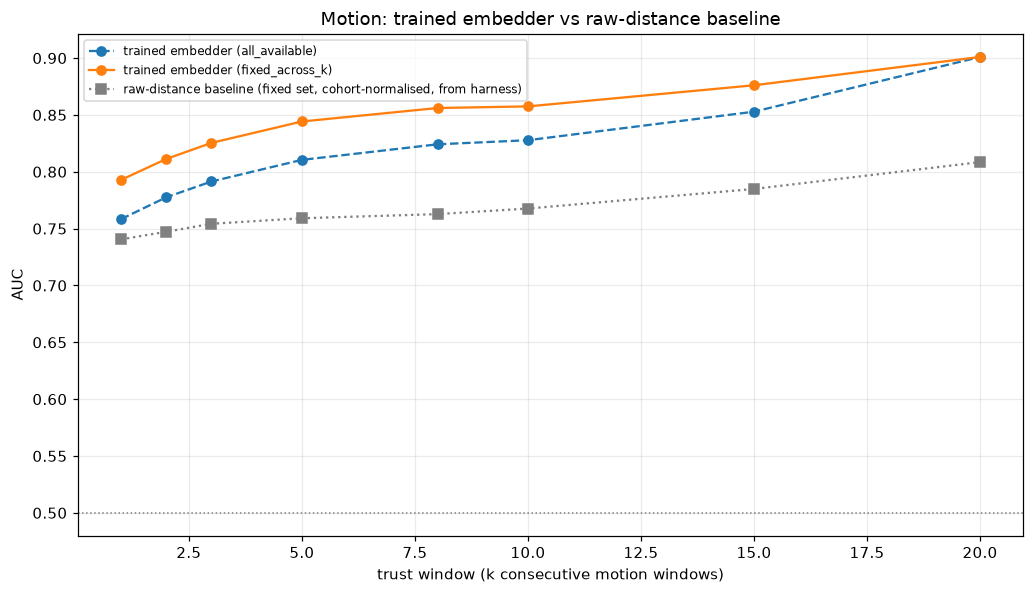


k -> elapsed time (median across trust windows, fixed_across_k identity set):
 k  median_span_s  auc
 1           15.0  0.8
 2           22.5  0.8
 3           30.0  0.8
 5           45.0  0.8
 8           67.5  0.9
10           82.5  0.9
15          120.0  0.9
20          157.5  0.9

AUC at k=20, all_available minus fixed_across_k: +0.000 (positive means the earlier, unfixed curve was inflated by identity dropout)
k= 1: embedder 0.793 vs baseline 0.741 (+0.052)
k= 2: embedder 0.811 vs baseline 0.747 (+0.064)
k= 3: embedder 0.825 vs baseline 0.754 (+0.071)
k= 5: embedder 0.844 vs baseline 0.759 (+0.085)
k= 8: embedder 0.856 vs baseline 0.763 (+0.093)
k=10: embedder 0.857 vs baseline 0.768 (+0.090)
k=15: embedder 0.876 vs baseline 0.785 (+0.091)
k=20: embedder 0.901 vs baseline 0.808 (+0.092)


In [9]:
trust_results_path = find(str(MOD_DIR / 'trust_window_results.csv'),
                           'trust_window_results.csv',
                           '/mnt/user-data/uploads/trust_window_results.csv')
_trust_df = pd.read_csv(trust_results_path)
_baseline_rows = _trust_df[(_trust_df['modality']=='motion') & (_trust_df['identity_set']=='fixed_across_k')]
BASELINE_AUC = dict(zip(_baseline_rows['k_windows'], _baseline_rows['auc_cohort_norm']))
if not BASELINE_AUC:
    print("WARNING: no motion/fixed_across_k rows found in trust_window_results.csv -- "
          "either re-run evaluate_trust_windows.py, or this modality was skipped there entirely "
          "for having fewer than 2 fixed identities. The overlay below will just be empty in that case.")
else:
    print(f"Loaded baseline AUC for k={sorted(BASELINE_AUC.keys())} from {trust_results_path}")

fig, ax = plt.subplots(figsize=(9.5, 5.5))
for label, style in [('all_available', '--'), ('fixed_across_k', '-')]:
    sub = res_df[res_df['identity_set']==label].sort_values('k')
    ax.plot(sub['k'], sub['auc'], marker='o', ls=style, label=f'trained embedder ({label})')
bl_k = [k for k in k_values if k in BASELINE_AUC]
if bl_k:
    ax.plot(bl_k, [BASELINE_AUC[k] for k in bl_k], marker='s', ls=':', color='gray',
            label='raw-distance baseline (fixed set, cohort-normalised, from harness)')
ax.axhline(0.5, color='gray', ls=':', lw=1)
ax.set_xlabel('trust window (k consecutive motion windows)'); ax.set_ylabel('AUC')
ax.set_title('Motion: trained embedder vs raw-distance baseline')
ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig(PLOTS_DIR / '03_embedder_vs_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

# Elapsed-time reading of the same k-axis, using each k's ACTUAL median
# wall-clock span (see score_probe_windows docstring) rather than an
# assumed window-length/stride constant -- that decision is still
# unresolved for P2's pipeline (see subsec:p2-pipeline), so nothing here
# should presume a value. This is the same curve as above, just read as
# "AUC after N seconds of observation" instead of "AUC after k windows".
_span_label = 'fixed_across_k' if (res_df['identity_set']=='fixed_across_k').any() else 'all_available'
_span_table = res_df[res_df['identity_set']==_span_label][['k', 'median_span_s', 'auc']].sort_values('k')
print(f"\nk -> elapsed time (median across trust windows, {_span_label} identity set):")
print(_span_table.to_string(index=False, float_format=lambda v: f'{v:.1f}'))

drop_at_20 = (res_df[(res_df['identity_set']=='all_available')&(res_df['k']==20)]['auc'].iloc[0] -
              res_df[(res_df['identity_set']=='fixed_across_k')&(res_df['k']==20)]['auc'].iloc[0]) \
             if ((res_df['identity_set']=='fixed_across_k')&(res_df['k']==20)).any() else float('nan')
print(f"\nAUC at k=20, all_available minus fixed_across_k: {drop_at_20:+.3f} "
      f"(positive means the earlier, unfixed curve was inflated by identity dropout)"
      if drop_at_20 == drop_at_20 else "\nk=20 not evaluable on the fixed set.")

for k in bl_k:
    trained = res_df[(res_df['identity_set']=='fixed_across_k')&(res_df['k']==k)]['auc']
    if len(trained):
        print(f"k={k:2d}: embedder {trained.iloc[0]:.3f} vs baseline {BASELINE_AUC[k]:.3f} "
              f"({trained.iloc[0]-BASELINE_AUC[k]:+.3f})")


## 7. Multi-seed stability (fixed identity set)

In [10]:
SEEDS = [7, 13, 42]
seed_results = []
for seed in SEEDS:
    print(f"seed {seed}...")
    ckpt_s = CKPT_DIR / f'seed{seed}_{fp}.pt'
    if ckpt_s.exists() and not FORCE_RETRAIN:
        m = Embedder(len(feats), EMBED_DIM)
        m.load_state_dict(torch.load(ckpt_s, weights_only=False)['state_dict'])
    else:
        m, _ = train_embedder(X_all, y_all, role_all, seed=seed, verbose=False)
        torch.save({'state_dict': m.state_dict()}, ckpt_s)
    Es = embed(m, X_all)
    sc, _ = score_probe_windows(Es, y_all, df_idx, role_all, [1, 10, 20])
    rk, _ = summarise(sc, fixed_identities=fixed_identities, label='fixed_across_k')
    rk['seed'] = seed
    seed_results.append(rk)

seed_df = pd.concat(seed_results, ignore_index=True)
summary = seed_df.groupby('k')['auc'].agg(['mean', 'std'])
print(summary.round(3).to_string())

seed 7...
seed 13...
seed 42...
     mean    std
k               
1   0.790  0.003
10  0.852  0.007
20  0.891  0.018


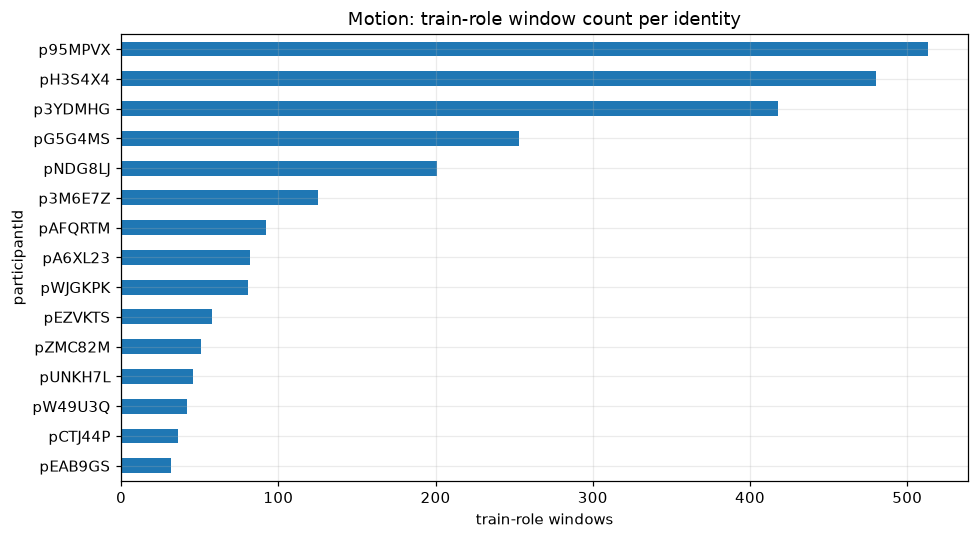

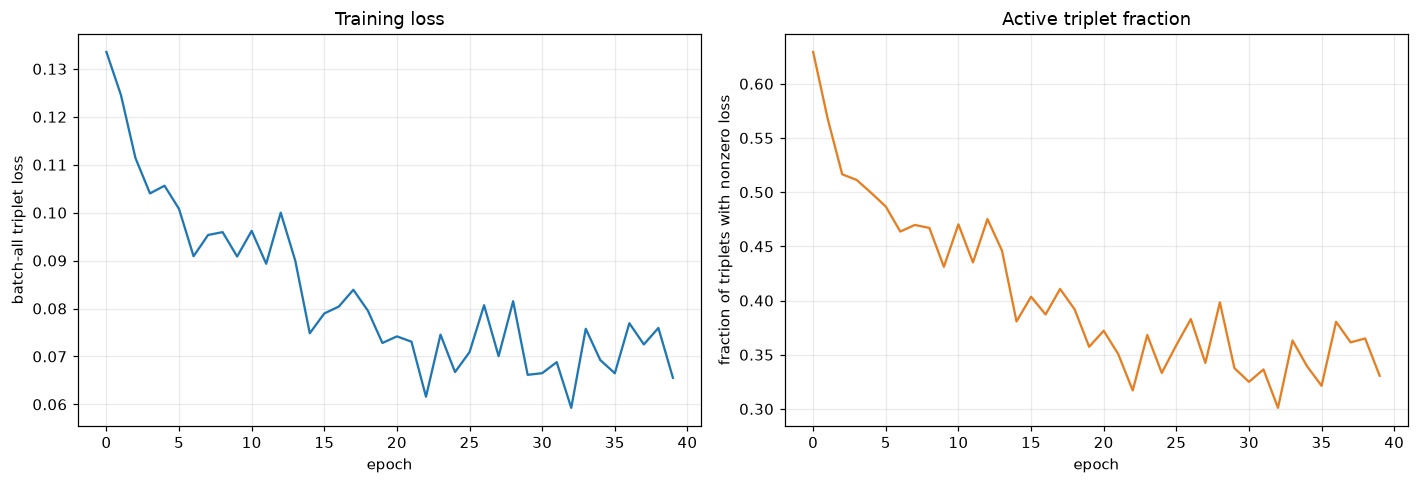

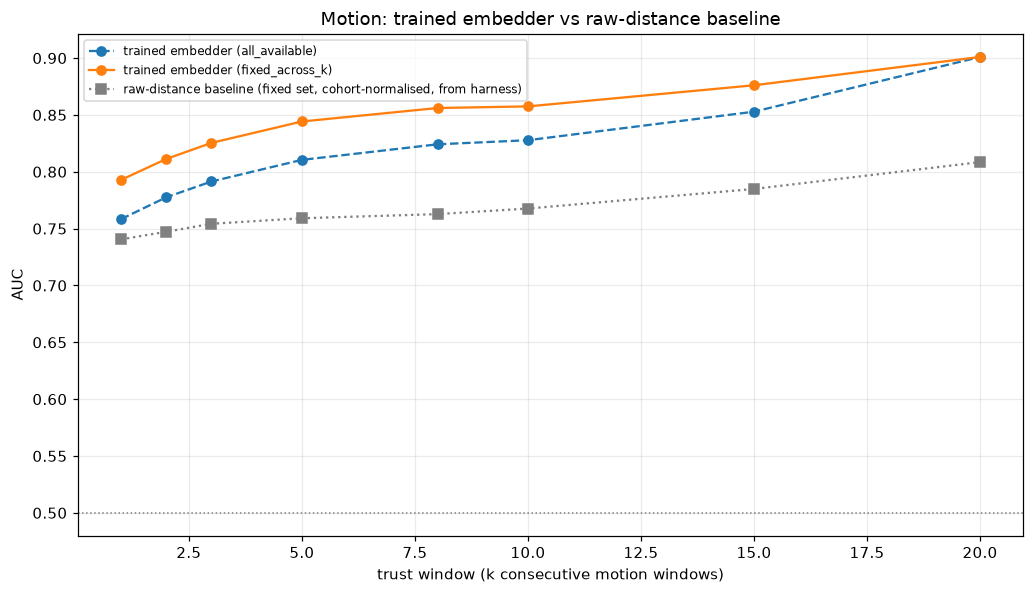

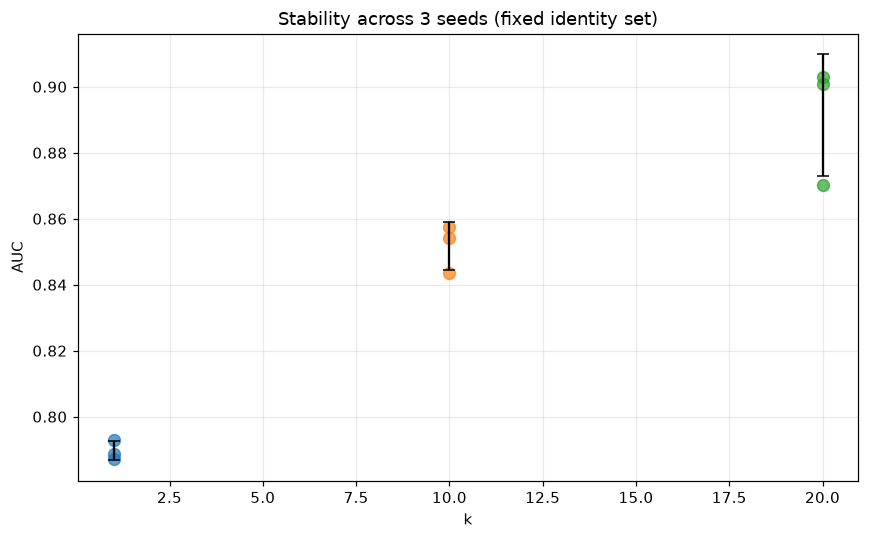

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
for k in seed_df['k'].unique():
    vals = seed_df[seed_df['k']==k]['auc']
    ax.scatter([k]*len(vals), vals, alpha=0.7, s=60)
ax.errorbar(summary.index, summary['mean'], yerr=summary['std'], fmt='none', color='k', capsize=4)
ax.set_xlabel('k'); ax.set_ylabel('AUC'); ax.set_title(f'Stability across {len(SEEDS)} seeds (fixed identity set)')
plt.tight_layout()
fig.savefig(PLOTS_DIR / '04_seed_stability.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Negative control -- trained model, fixed identity set

In [12]:
def compute_fixed_identities(y, role, refs, k_values):
    max_k = max(k_values)
    probe_mask = role == 'probe'
    probe_counts = pd.Series(y[probe_mask]).value_counts()
    return set(probe_counts[probe_counts >= max_k].index) & set(refs.keys())

def shuffle_labels(y, df_meta, seed):
    rng = np.random.default_rng(seed)
    sess_pid = df_meta.groupby('sessionId')['participantId'].first()
    mapping = dict(zip(sess_pid.index, rng.permutation(sess_pid.values)))
    return df_meta['sessionId'].map(mapping).values

def filter_leaked_identities(y_shuf, role, fixed_ids, df_meta):
    # Drops any shuffled fake identity where ANY real participant appears
    # in both its enrol and probe windows (not just the dominant one).
    # On tap (nb15), this and a device-family confound (mobile vs desktop)
    # were both confirmed as ruled out for the residual per-seed AUC spread
    # -- what's left after this filter is small-N noise from scoring
    # against as few as 1-3 clean identities per seed, not leakage. Worth
    # re-checking the per-seed diagnostic print below for motion rather
    # than assuming the same conclusion transfers automatically.
    enrol_mask, probe_mask = role == 'enrol', role == 'probe'
    clean, dropped = set(), []
    for fake_pid in fixed_ids:
        e_true = set(df_meta.loc[enrol_mask & (y_shuf == fake_pid), 'participantId'])
        p_true = set(df_meta.loc[probe_mask & (y_shuf == fake_pid), 'participantId'])
        if not e_true or not p_true:
            continue
        overlap = e_true & p_true
        if overlap:
            dropped.append((fake_pid, sorted(overlap)))
            continue
        clean.add(fake_pid)
    return clean, dropped

CONTROL_K_VALUES = [1, 10, 20]
SEEDS_CONTROL = list(range(8))  # widened from [0,1,2] -- with as few as 1-3
# clean identities surviving the leakage filter in some seeds, AUC over so
# few identities is inherently noisy (same small-N instability documented
# for P1's n=2 desktop evaluation); more seeds are needed to separate a
# real residual effect from an unlucky draw. Report mean/std across all
# seeds rather than treating any single seed as definitive.
control_results = []
control_fixed_id_counts = []
for seed in SEEDS_CONTROL:
    y_shuf = shuffle_labels(y_all, df_idx, seed)
    ckpt_c = CKPT_DIR / f'control{seed}_{fp}.pt'
    if ckpt_c.exists() and not FORCE_RETRAIN:
        m = Embedder(len(feats), EMBED_DIM)
        m.load_state_dict(torch.load(ckpt_c, weights_only=False)['state_dict'])
    else:
        m, _ = train_embedder(X_all, y_shuf, role_all, seed=seed, verbose=False)
        torch.save({'state_dict': m.state_dict()}, ckpt_c)
    Ec = embed(m, X_all)
    sc, refs_c = score_probe_windows(Ec, y_shuf, df_idx, role_all, CONTROL_K_VALUES)
    fixed_identities_shuf = compute_fixed_identities(y_shuf, role_all, refs_c, CONTROL_K_VALUES)
    fixed_identities_shuf, leaked = filter_leaked_identities(y_shuf, role_all, fixed_identities_shuf, df_idx)
    control_fixed_id_counts.append({'seed': seed, 'n_fixed_identities': len(fixed_identities_shuf),
                                     'n_leaked_dropped': len(leaked)})
    print(f"  seed {seed}: {len(fixed_identities_shuf)} clean fixed identities under shuffled labels"
          + (f" -- dropped {len(leaked)} leaked: {leaked}" if leaked else ""))
    rk, _ = summarise(sc, fixed_identities=fixed_identities_shuf, label='fixed_across_k')
    rk['seed'] = seed
    control_results.append(rk)

control_df = pd.concat(control_results, ignore_index=True)
control_fixed_id_df = pd.DataFrame(control_fixed_id_counts)
print()
print("per-seed fixed-identity-set size (diagnostic):")
print(control_fixed_id_df.to_string(index=False))
print()
print("per-seed raw AUC (diagnostic):")
print(control_df.pivot_table(index='seed', columns='k', values='auc').round(3).to_string())

ctrl_summary = control_df.groupby('k')['auc'].agg(['mean', 'std'])
print(); print(f"shuffled-label control (mean/std across {len(SEEDS_CONTROL)} seeds):")
print(ctrl_summary.round(3).to_string())
compare = summary[['mean']].join(ctrl_summary[['mean']], lsuffix='_real', rsuffix='_shuffled')
compare['gap'] = compare['mean_real'] - compare['mean_shuffled']
print(); print(compare.round(3).to_string())


  seed 0: 5 clean fixed identities under shuffled labels -- dropped 1 leaked: [('pEAB9GS', ['p3M6E7Z'])]
  seed 1: 2 clean fixed identities under shuffled labels -- dropped 1 leaked: [('p95MPVX', ['pUNKH7L'])]
  seed 2: 2 clean fixed identities under shuffled labels -- dropped 1 leaked: [('p95MPVX', ['pEZVKTS'])]
  seed 3: 1 clean fixed identities under shuffled labels -- dropped 2 leaked: [('pH3S4X4', ['p95MPVX']), ('pG5G4MS', ['pH3S4X4'])]
  seed 4: 3 clean fixed identities under shuffled labels -- dropped 1 leaked: [('pH3S4X4', ['pNDG8LJ'])]
  seed 5: 3 clean fixed identities under shuffled labels -- dropped 2 leaked: [('p3YDMHG', ['pH3S4X4']), ('pH3S4X4', ['p3M6E7Z'])]
  seed 6: 2 clean fixed identities under shuffled labels -- dropped 1 leaked: [('p3YDMHG', ['pG5G4MS', 'pUNKH7L'])]
  seed 7: 2 clean fixed identities under shuffled labels -- dropped 2 leaked: [('pNDG8LJ', ['p3YDMHG']), ('pG5G4MS', ['pA6XL23'])]

per-seed fixed-identity-set size (diagnostic):
 seed  n_fixed_identiti

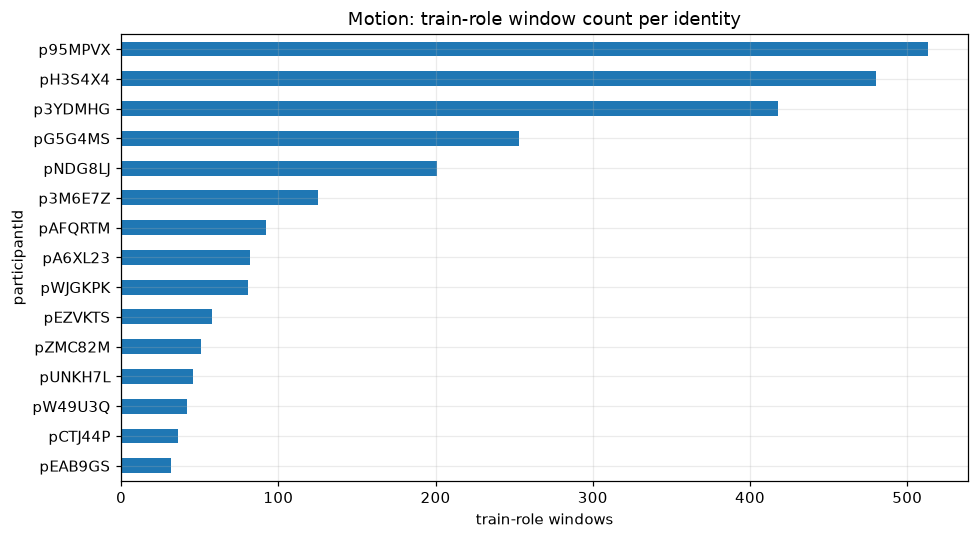

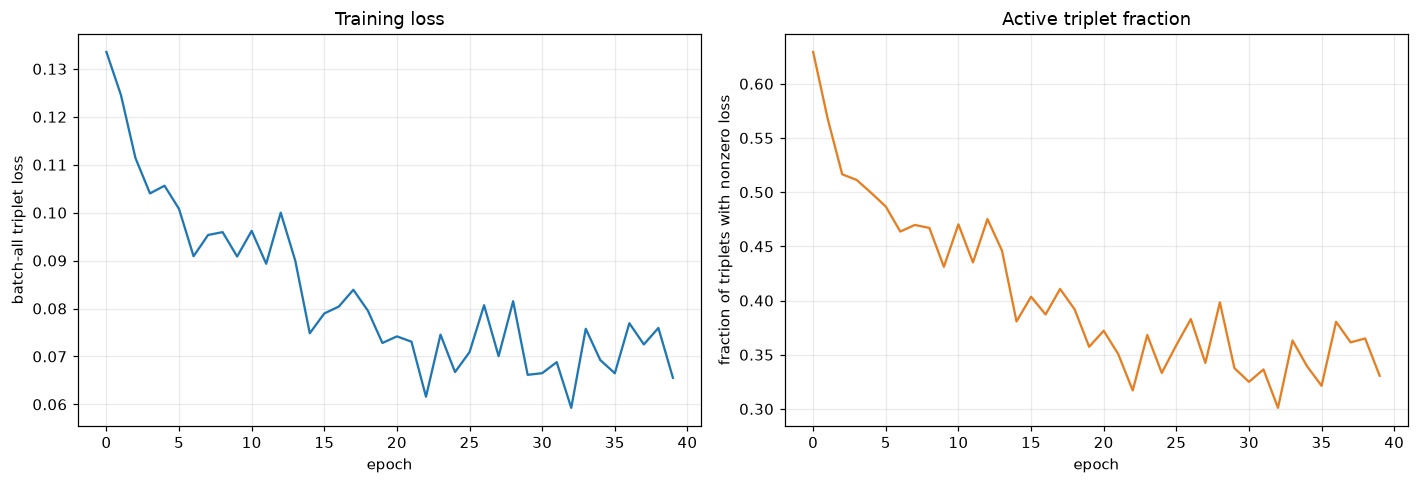

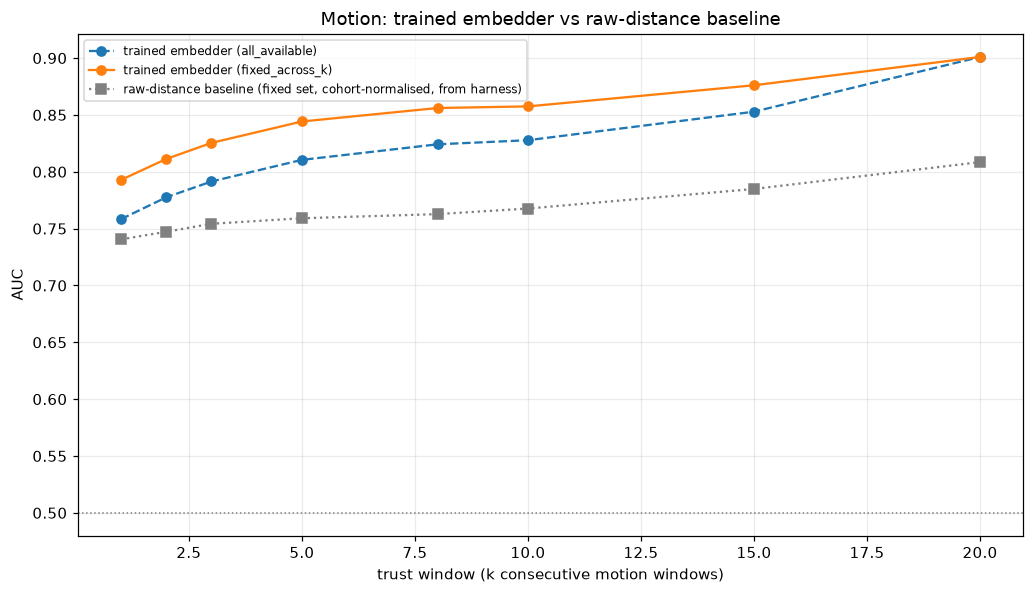

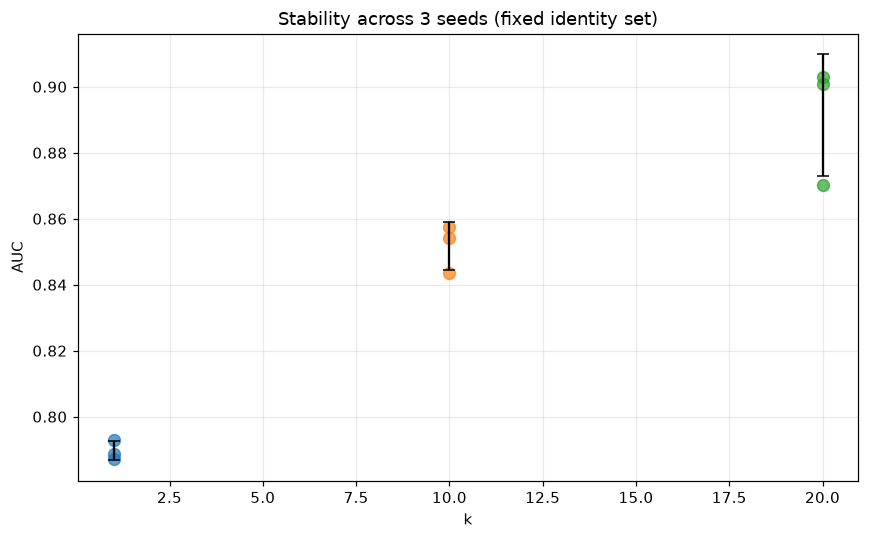

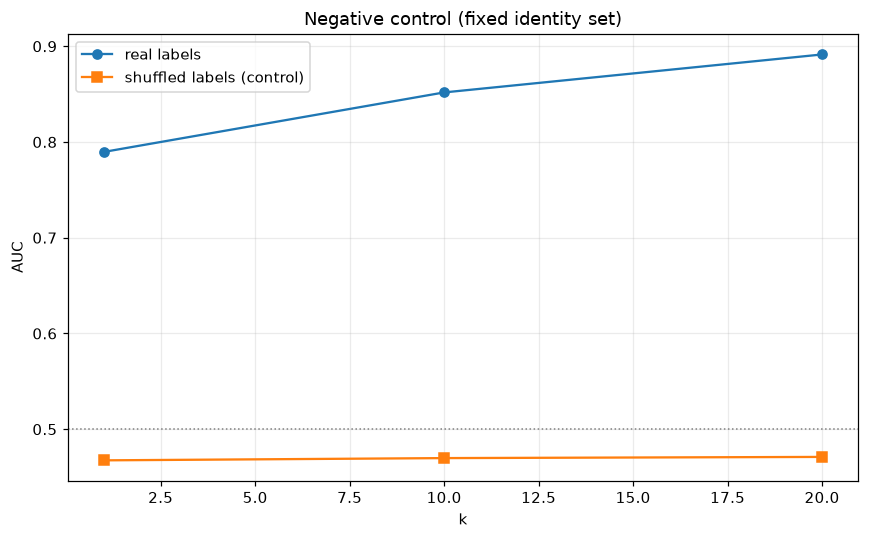

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(summary.index, summary['mean'], marker='o', label='real labels')
ax.plot(ctrl_summary.index, ctrl_summary['mean'], marker='s', label='shuffled labels (control)')
ax.axhline(0.5, color='gray', ls=':', lw=1)
ax.set_xlabel('k'); ax.set_ylabel('AUC'); ax.set_title('Negative control (fixed identity set)')
ax.legend()
plt.tight_layout()
fig.savefig(PLOTS_DIR / '05_negative_control.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Permutation feature importance

Same method as nb14: shuffle one feature at a time across probe windows,
recompute embeddings with the already-trained model, measure the AUC drop
at k=1 -- model-agnostic, no retraining needed.

In [14]:
rng = np.random.default_rng(0)
probe_mask = role_all == 'probe'
baseline_scored, _ = score_probe_windows(E_all, y_all, df_idx, role_all, [1])
baseline_res, _ = summarise(baseline_scored, fixed_identities=fixed_identities, label='fixed_across_k')
baseline_auc = baseline_res.loc[baseline_res['k']==1, 'auc'].iloc[0]
print(f"baseline (unpermuted) AUC at k=1: {baseline_auc:.3f}")

importances = []
X_perm_base = X_all.copy()
for j, feat_name in enumerate(feats):
    X_perm = X_perm_base.copy()
    perm_idx = rng.permutation(np.where(probe_mask)[0])
    X_perm[np.where(probe_mask)[0], j] = X_perm_base[perm_idx, j]
    E_perm = embed(model, X_perm)
    sc_perm, _ = score_probe_windows(E_perm, y_all, df_idx, role_all, [1])
    res_perm, _ = summarise(sc_perm, fixed_identities=fixed_identities, label='fixed_across_k')
    perm_auc = res_perm.loc[res_perm['k']==1, 'auc'].iloc[0] if len(res_perm) else np.nan
    importances.append({'feature': feat_name, 'auc_drop': baseline_auc - perm_auc})

importance_df = pd.DataFrame(importances).sort_values('auc_drop', ascending=False)
print(importance_df.head(15).to_string(index=False, float_format=lambda v: f'{v:.4f}'))

baseline (unpermuted) AUC at k=1: 0.793
                       feature  auc_drop
   motion_active_accel_mag_iqr    0.0635
    motion_active_accel_mag_cv    0.0305
              motion_idle_frac    0.0174
    motion_cross_axis_corr_p95    0.0122
     motion_idle_accel_mag_max    0.0098
 motion_cross_axis_corr_median    0.0093
     motion_idle_run_max_len_s    0.0048
  motion_cross_axis_corr_slope    0.0038
   motion_cross_axis_corr_mean    0.0029
motion_active_accel_mag_median    0.0028
   motion_idle_accel_mag_slope    0.0017
 motion_active_accel_mag_slope    0.0014
  motion_active_accel_mag_mean    0.0014
   motion_active_accel_mag_max    0.0002
     motion_cross_axis_corr_cv   -0.0002


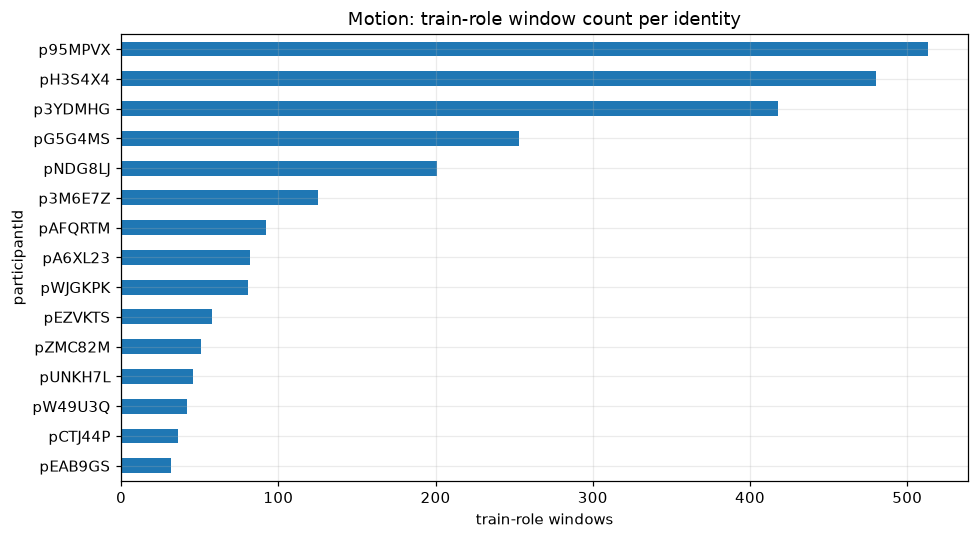

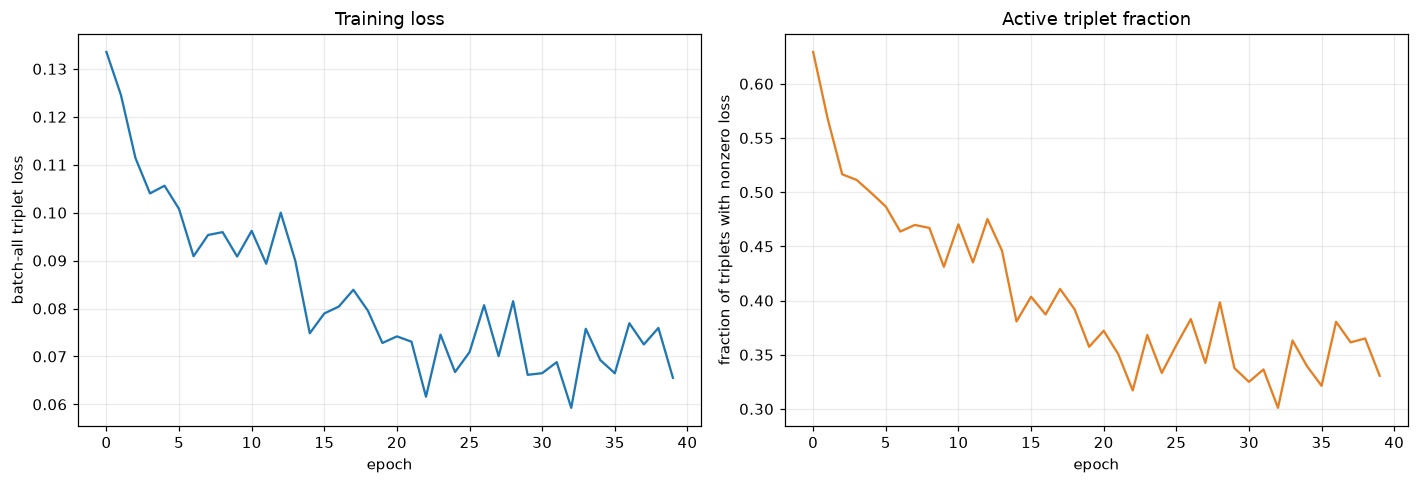

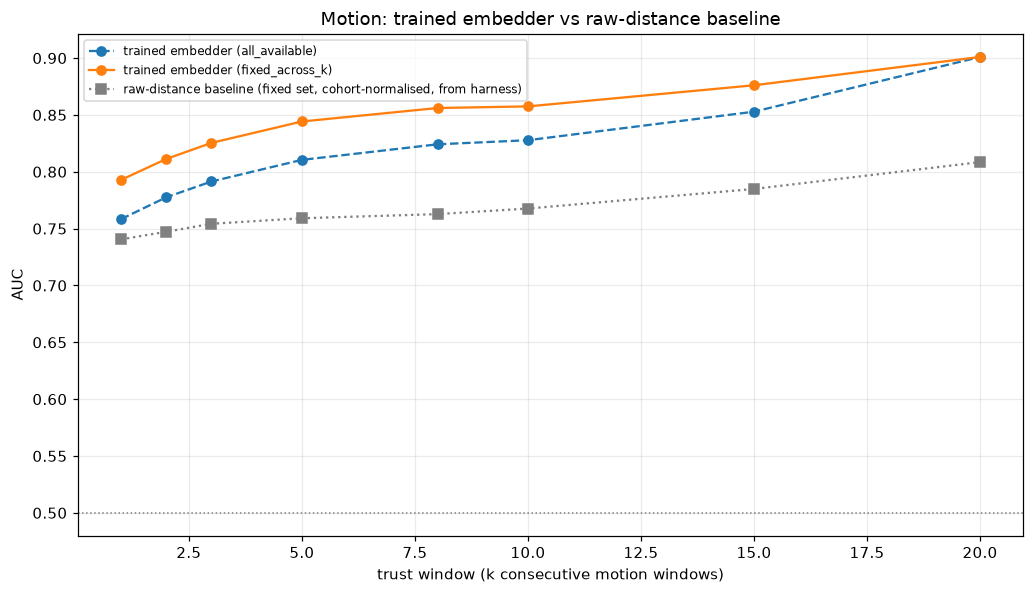

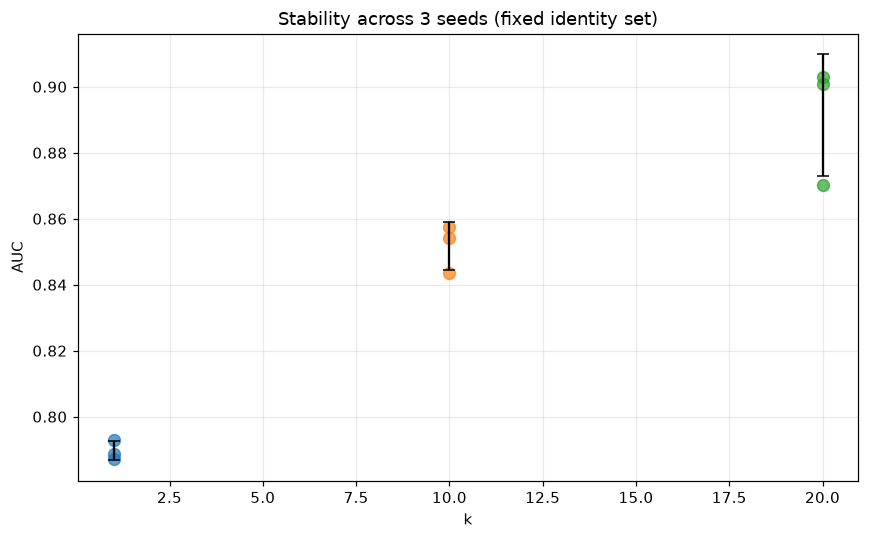

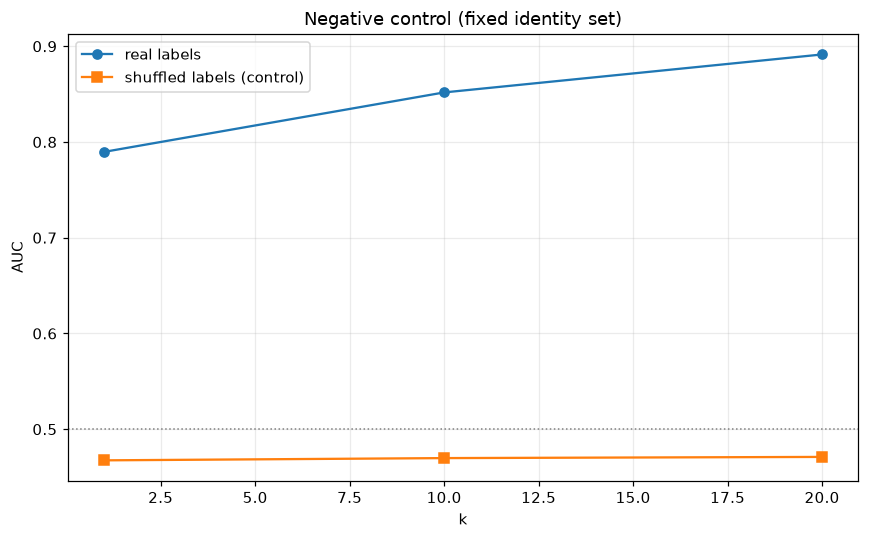

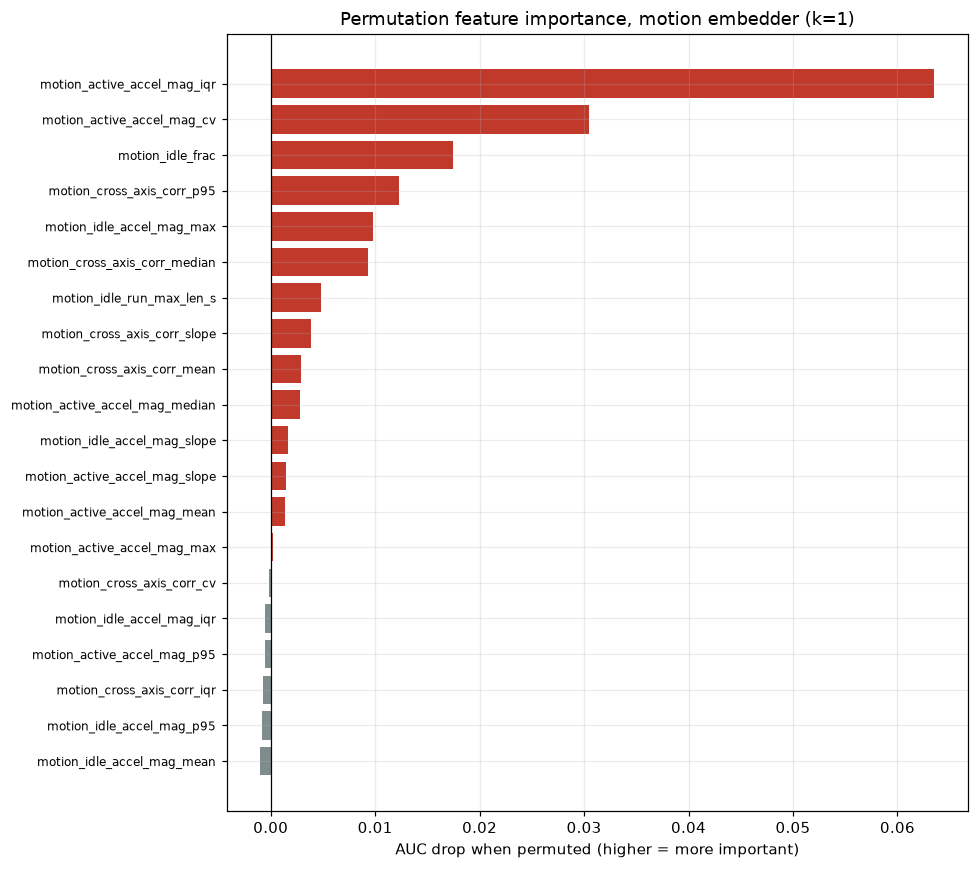


NOTE: 1 feature(s) show a NEGATIVE auc_drop (performance improved when permuted, i.e. removing their real signal helped) -- worth checking whether these are adding noise rather than signal, candidates for exclusion in a future feature-set pass.


In [15]:
fig, ax = plt.subplots(figsize=(9, 8))
top = importance_df.head(20).iloc[::-1]
ax.barh(range(len(top)), top['auc_drop'], color=['#c0392b' if v > 0 else '#7f8c8d' for v in top['auc_drop']])
ax.set_yticks(range(len(top))); ax.set_yticklabels(top['feature'], fontsize=8)
ax.axvline(0, color='k', lw=0.8)
ax.set_xlabel('AUC drop when permuted (higher = more important)')
ax.set_title('Permutation feature importance, motion embedder (k=1)')
plt.tight_layout()
fig.savefig(PLOTS_DIR / '07_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

n_negative = (importance_df['auc_drop'] < -0.005).sum()
if n_negative:
    print(f"\nNOTE: {n_negative} feature(s) show a NEGATIVE auc_drop (performance improved when "
          f"permuted, i.e. removing their real signal helped) -- worth checking whether these are "
          f"adding noise rather than signal, candidates for exclusion in a future feature-set pass.")


## 10. Embedding space, qualitatively

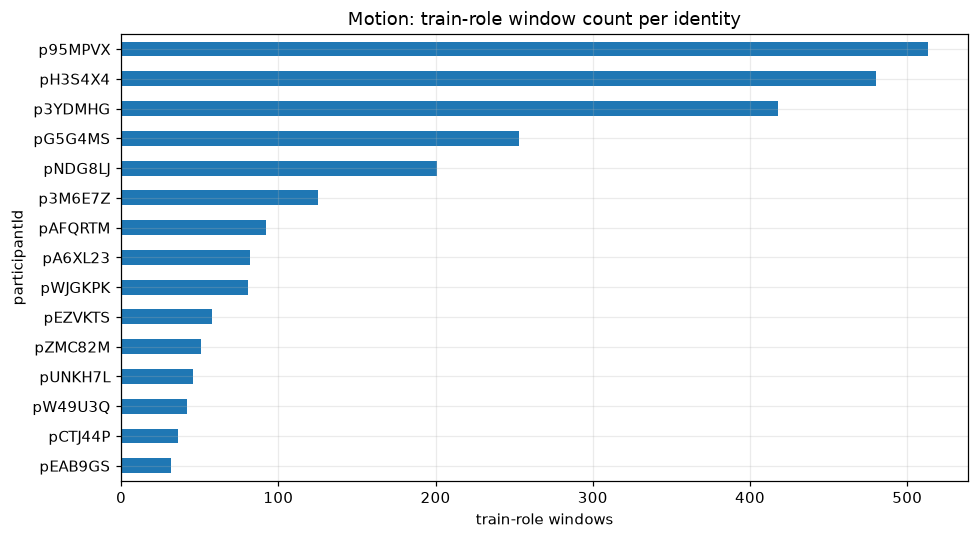

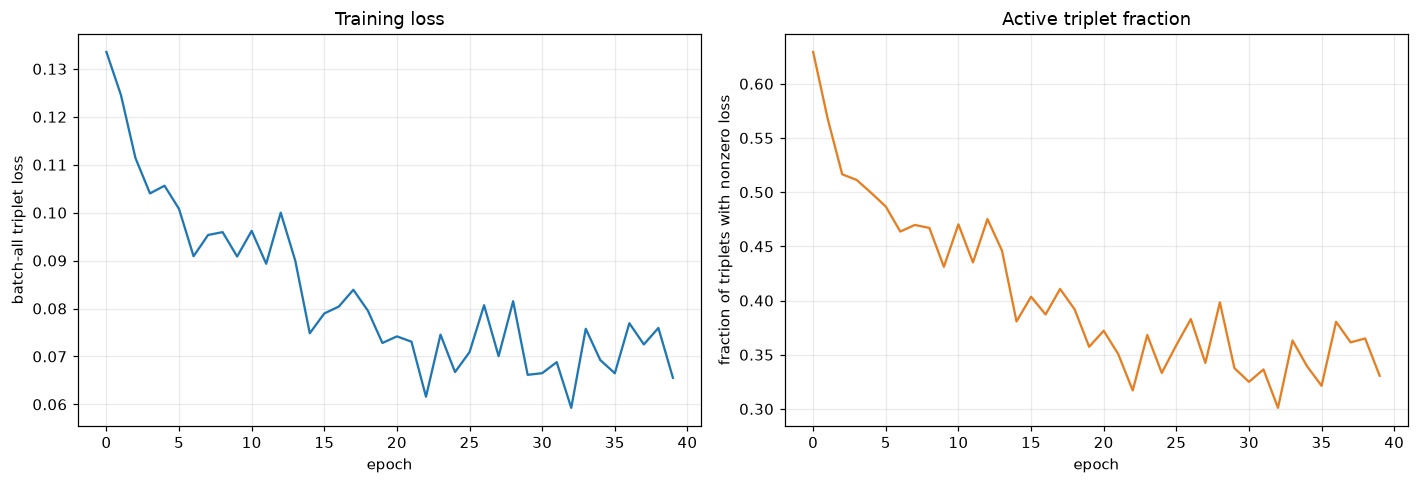

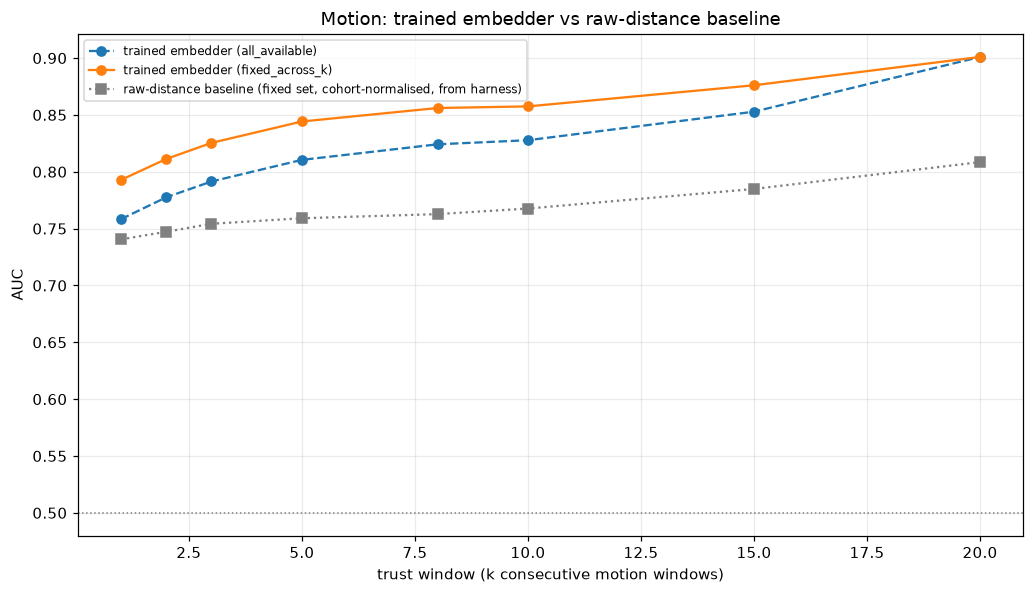

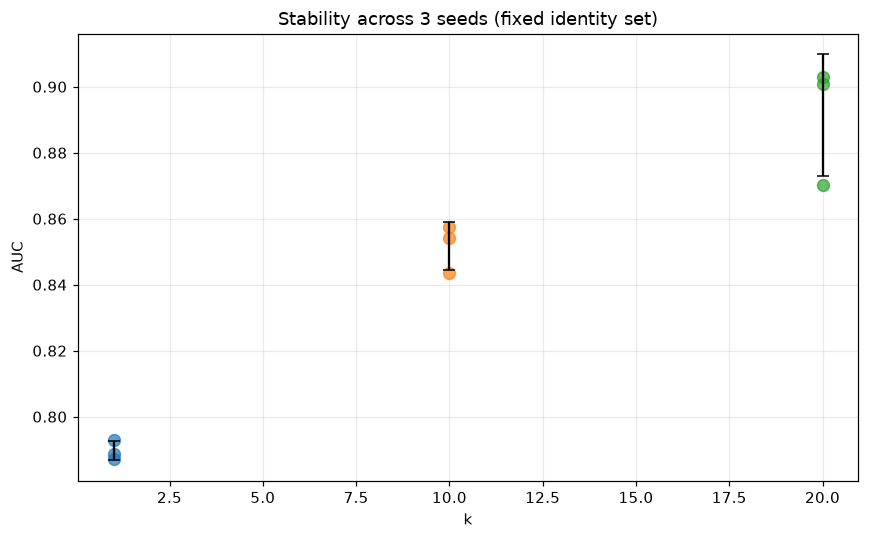

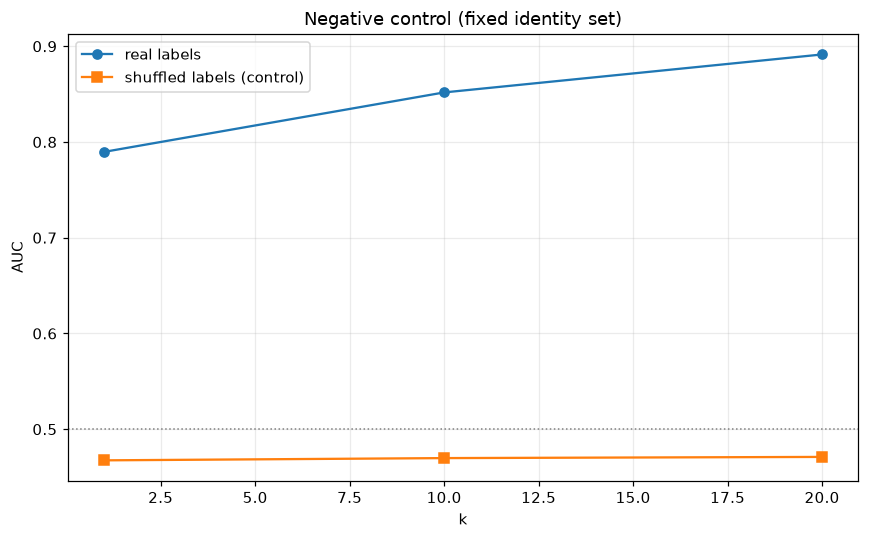

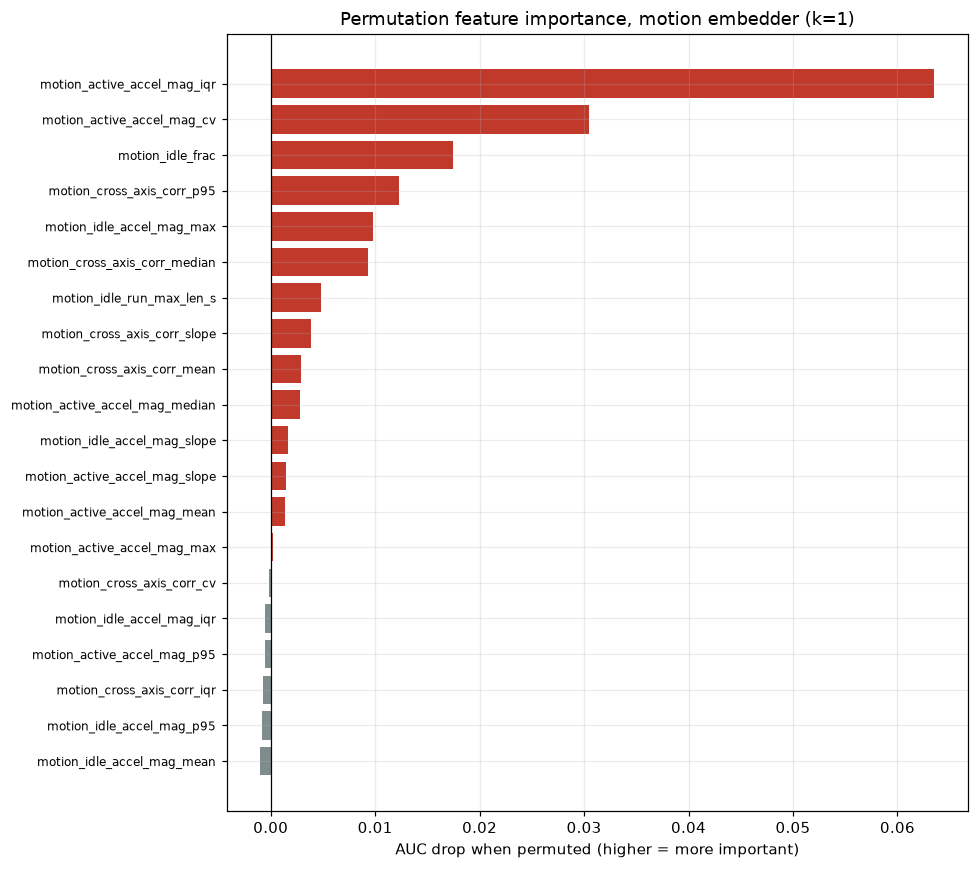

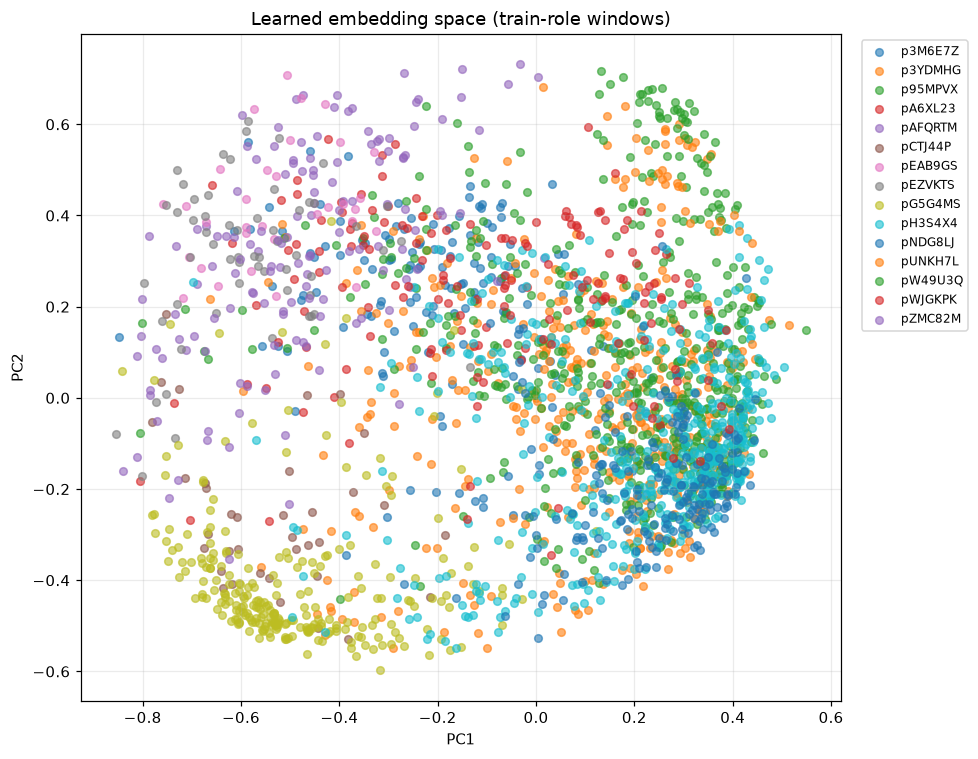

explained variance (first 2 PCs): [0.332 0.231]


In [16]:
with torch.no_grad():
    E_train = embed(model, X_all[role_all == 'train'])
y_train_plot = y_all[role_all == 'train']

pca = PCA(n_components=2).fit(E_train)
E2 = pca.transform(E_train)

fig, ax = plt.subplots(figsize=(9, 7))
for pid in np.unique(y_train_plot):
    m = y_train_plot == pid
    ax.scatter(E2[m, 0], E2[m, 1], label=pid, alpha=0.6, s=25)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_title('Learned embedding space (train-role windows)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
fig.savefig(PLOTS_DIR / '06_embedding_space_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"explained variance (first 2 PCs): {pca.explained_variance_ratio_.round(3)}")

## 11. Export

In [17]:
import json as _json
from datetime import datetime, timezone

# Every filename here is prefixed with the modality name -- a second line
# of defence on top of the OUT_DIR fix in Section 0.
PREFIX = 'motion_'

res_df.to_csv(OUT_DIR / f'{PREFIX}trained_vs_baseline.csv', index=False)
per_id_df.to_csv(OUT_DIR / f'{PREFIX}per_participant.csv', index=False)
loo_df.to_csv(OUT_DIR / f'{PREFIX}leave_one_out.csv', index=False)
seed_df.to_csv(OUT_DIR / f'{PREFIX}seed_stability_raw.csv', index=False)
summary.reset_index().to_csv(OUT_DIR / f'{PREFIX}seed_stability_summary.csv', index=False)
control_df.to_csv(OUT_DIR / f'{PREFIX}negative_control_raw.csv', index=False)
compare.reset_index().to_csv(OUT_DIR / f'{PREFIX}negative_control_summary.csv', index=False)
history.to_csv(OUT_DIR / f'{PREFIX}training_history_seed42.csv', index=False)
importance_df.to_csv(OUT_DIR / f'{PREFIX}feature_importance.csv', index=False)

torch.save({'state_dict': model.state_dict(), 'feature_names': feats, 'embed_dim': EMBED_DIM},
           OUT_DIR / f'{PREFIX}model_seed42.pt')
np.savez(OUT_DIR / f'{PREFIX}preprocessing.npz', impute_values=imputer.statistics_,
         scale_mean=scaler.mean_, scale_scale=scaler.scale_,
         feature_names=np.array(feats, dtype=object))

manifest = {
    'generated_at_utc': datetime.now(timezone.utc).isoformat(),
    'modality': 'motion', 'data_fingerprint': fp,
    'n_windows': int(len(df)), 'n_features': len(feats),
    'n_reference_identities': len(refs), 'n_fixed_identities': len(fixed_identities),
    'fixed_identities': sorted(fixed_identities),
    'architecture': '256-128-32 MLP, dropout 0.10, L2-normalised output',
    'max_batches_per_epoch': MAX_BATCHES_PER_EPOCH, 'epochs': EPOCHS, 'seeds_run': SEEDS,
    'baseline_source': 'trust_window_results.csv, motion/fixed_across_k/auc_cohort_norm (loaded dynamically)',
    'auc_real_fixed_at_k1_k10_k20': {int(k): round(float(v), 3) for k, v in summary['mean'].items()},
    'auc_shuffled_fixed_at_k1_k10_k20': {int(k): round(float(v), 3) for k, v in ctrl_summary['mean'].items()},
    'leave_one_out_at_k20': {str(k): round(float(v), 3) for k, v in loo.items()},
    'files': sorted(p.name for p in OUT_DIR.iterdir() if p.is_file()) +
             ['plots/' + p.name for p in PLOTS_DIR.iterdir()],
}
with open(OUT_DIR / f'{PREFIX}manifest.json', 'w') as f:
    _json.dump(manifest, f, indent=2)

print(f"Wrote to {OUT_DIR.resolve()}:")
for p in sorted(OUT_DIR.rglob('*')):
    if p.is_file():
        print(f"  {p.relative_to(OUT_DIR)}  ({p.stat().st_size / 1024:.1f} KB)")


Wrote to /Users/will/Documents/BBDC-Prototype-2-Research/data/processed/motion_embedder:
  checkpoints/control0_6117f61920c55387.pt  (174.6 KB)
  checkpoints/control0_9356c6ce49e05714.pt  (174.6 KB)
  checkpoints/control1_6117f61920c55387.pt  (174.6 KB)
  checkpoints/control1_9356c6ce49e05714.pt  (174.6 KB)
  checkpoints/control2_6117f61920c55387.pt  (174.6 KB)
  checkpoints/control2_9356c6ce49e05714.pt  (174.6 KB)
  checkpoints/control3_6117f61920c55387.pt  (174.6 KB)
  checkpoints/control3_9356c6ce49e05714.pt  (174.6 KB)
  checkpoints/control4_6117f61920c55387.pt  (174.6 KB)
  checkpoints/control4_9356c6ce49e05714.pt  (174.6 KB)
  checkpoints/control5_6117f61920c55387.pt  (174.6 KB)
  checkpoints/control5_9356c6ce49e05714.pt  (174.6 KB)
  checkpoints/control6_6117f61920c55387.pt  (174.6 KB)
  checkpoints/control6_9356c6ce49e05714.pt  (174.6 KB)
  checkpoints/control7_6117f61920c55387.pt  (174.6 KB)
  checkpoints/control7_9356c6ce49e05714.pt  (174.6 KB)
  checkpoints/primary_seed42_61

## How to avoid the wait on repeat runs

Same guidance as nb14/nb15: don't Restart & Run All unless something
upstream changed; `FORCE_RETRAIN = False` reloads all trained models from
`checkpoints/` keyed on a data/feature/role fingerprint; lower
`MAX_BATCHES_PER_EPOCH` for a quick sanity check while iterating on
unrelated cells; Sections 7-8 are the majority of total trainings, so
comment out seeds/controls you don't need while iterating on something
else.
